In [32]:
import numpy as np
import matplotlib.pyplot as plt
!pip install japanize-matplotlib
import japanize_matplotlib
import torch
!pip install torchviz
from torchviz import make_dot
import torch.optim as optim


# 勾配計算機能を利用した線形回帰

## データ前処理

In [33]:
sampleData1 = np.array([
    [166, 58.7],
    [176, 75.7],
    [171, 62.1],
    [173, 70.4],
    [169, 60.1]
])

x = sampleData1[:, 0] # 入力データ
y = sampleData1[:, 1] # 正解データ


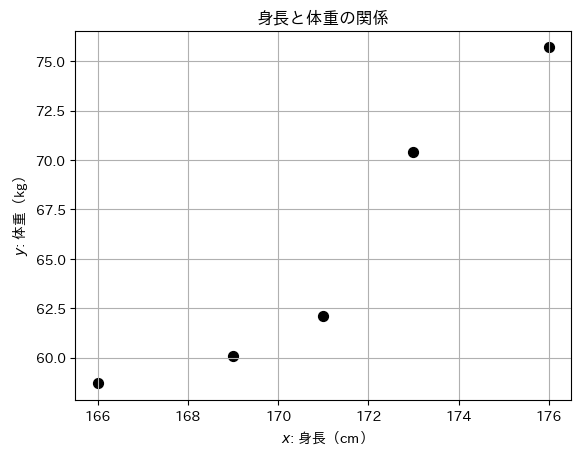

In [34]:
plt.scatter(x, y, c='k', s=50)
plt.xlabel("$x$: 身長（cm）")
plt.ylabel("$y$: 体重（kg）")
plt.title("身長と体重の関係")
plt.grid()
plt.show()


### 標準化
参考：https://qiita.com/ttskng/items/2a33c1ca925e4501e609#なぜfeature-scalingをするのか

In [35]:
x_mean = x.mean()
x_std = x.std()

y_mean = y.mean()
y_std = y.std()

X = (x - x_mean) / x_std
Y = (y - y_mean) / y_std


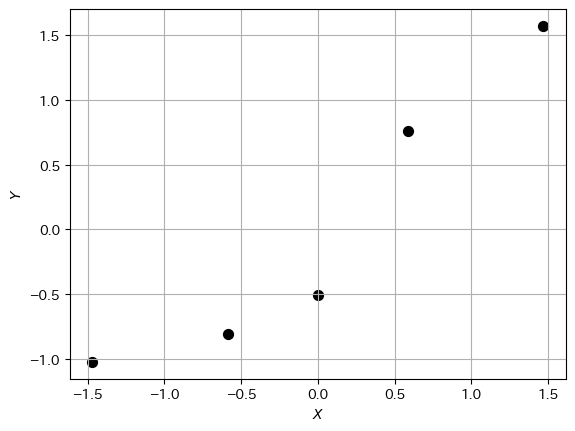

In [36]:
plt.scatter(X, Y, c='k', s=50)
plt.xlabel('$X$')
plt.ylabel('$Y$')
plt.grid()
plt.show()


## 予測計算

### データのテンソル化

In [37]:
X = torch.tensor(X, dtype=torch.float32)
Y = torch.tensor(Y, dtype=torch.float32)

print(X)
print(Y)


tensor([-1.4681,  1.4681,  0.0000,  0.5872, -0.5872])
tensor([-1.0218,  1.5709, -0.5033,  0.7626, -0.8083])


### 重みWとバイアスBの定義

In [38]:
W = torch.tensor(1.0, requires_grad=True, dtype=torch.float32)
B = torch.tensor(1.0, requires_grad=True, dtype=torch.float32)


### $Y_p = W \cdot X + B$

In [39]:
# 予測関数は1次関数
def pred(X):
    return W * X + B

# 予測値の計算例
Yp = pred(X)
print(Yp)


tensor([-0.4681,  2.4681,  1.0000,  1.5872,  0.4128], grad_fn=<AddBackward0>)


### 計算グラフ

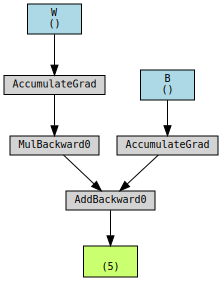

In [40]:
params = {'W': W, 'B': B}
g = make_dot(Yp, params=params)
display(g)


## 損失計算

### 損失関数の定義

In [41]:
def mse(Yp, Y):
    """平均2乗誤差"""
    loss = ((Yp - Y) ** 2).mean()
    return loss

loss = mse(Yp=Yp, Y=Y)
print(loss)


tensor(1.1085, grad_fn=<MeanBackward0>)


### 損失の計算グラフ
「損失」とは，「予測関数」と「損失関数」の合成関数である．

Mul・Addが予測関数で，Sub・Pow・MeanがMSE．

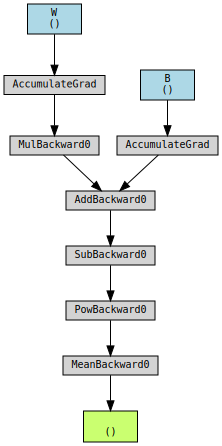

In [42]:
params = {'W': W, 'B': B}
g = make_dot(loss, params=params)
display(g)


## 勾配計算

In [43]:
loss.backward() # 勾配計算

print(W.grad)
print(B.grad)


tensor(0.1085)
tensor(2.)


### パラメータ修正（誤り）
勾配計算をしている最中の変数は，他に影響が及んでしまうため勝手に値を修正できない．

In [44]:
"""
lr = 0.001

W -= lr * W.grad
B -= lr * B.grad
"""


'\nlr = 0.001\n\nW -= lr * W.grad\nB -= lr * B.grad\n'

### パラメータ修正（正解）
with torch.no_grad()というコンテキストを設定すると，そのコンテキストの内部では一時的に計算グラフ生成が止まり，変数の修正が可能になる．パラメータ更新の計算をグラフに記録せずに更新できる．

In [45]:
lr = 0.001 # learning rate

# 勾配を基にパラメータ修正
# with torch.no_grad()を付ける必要がある．
with torch.no_grad():
    W -= lr * W.grad
    B -= lr * B.grad

# 忘れずに勾配を初期化
W.grad.zero_()
B.grad.zero_()


tensor(0.)

## 繰り返し計算

### 初期化

In [46]:
W = torch.tensor(1.0, requires_grad=True, dtype=torch.float32)
B = torch.tensor(1.0, requires_grad=True, dtype=torch.float32)

num_epochs = 5000 # 繰り返し回数
lr = 0.001 # 学習率

# 損失の記録用配列
history = np.zeros((0, 2)) # 2個の値を1セットとして，あとからどんどん追加する．


### ループ処理

In [47]:
for epoch in range(num_epochs):
    Yp = pred(X) # 予測計算
    loss = mse(Yp, Y) # 損失計算
    loss.backward() # 勾配計算

    with torch.no_grad():
        # パラメータ修正
        W -= lr * W.grad
        B -= lr * B.grad

        # 勾配値の初期化（パラメータ更新が終わったので．）
        W.grad.zero_()
        B.grad.zero_()
    
    if ((epoch % 10) == 0):
        item = np.array([epoch, loss.item()])
        history = np.vstack((history, item)) # vertical stack: 行を追加する．引数で「配列の集合」を渡す．
        print(f"epoch = {epoch}, loss = {loss:.4f}")


epoch = 0, loss = 1.1085
epoch = 10, loss = 1.0692
epoch = 20, loss = 1.0313
epoch = 30, loss = 0.9950
epoch = 40, loss = 0.9601
epoch = 50, loss = 0.9266
epoch = 60, loss = 0.8943
epoch = 70, loss = 0.8634
epoch = 80, loss = 0.8336
epoch = 90, loss = 0.8051
epoch = 100, loss = 0.7776
epoch = 110, loss = 0.7512
epoch = 120, loss = 0.7259
epoch = 130, loss = 0.7015
epoch = 140, loss = 0.6781
epoch = 150, loss = 0.6557
epoch = 160, loss = 0.6341
epoch = 170, loss = 0.6133
epoch = 180, loss = 0.5934
epoch = 190, loss = 0.5743
epoch = 200, loss = 0.5559
epoch = 210, loss = 0.5382
epoch = 220, loss = 0.5212
epoch = 230, loss = 0.5049
epoch = 240, loss = 0.4892
epoch = 250, loss = 0.4742
epoch = 260, loss = 0.4597
epoch = 270, loss = 0.4458
epoch = 280, loss = 0.4325
epoch = 290, loss = 0.4196
epoch = 300, loss = 0.4073
epoch = 310, loss = 0.3955
epoch = 320, loss = 0.3841
epoch = 330, loss = 0.3731
epoch = 340, loss = 0.3626
epoch = 350, loss = 0.3526
epoch = 360, loss = 0.3429
epoch = 370,

## 結果評価

In [48]:
# パラメータの最終値
print('W =', W.item())
print('B =', B.item())

# 損失の確認
print(f"初期状態: 損失: {history[0, 1]:.4f}")
print(f"最終状態: 損失: {history[-1, 1]:.4f}")


W = 0.9457533955574036
B = 4.49487597506959e-05
初期状態: 損失: 1.1085
最終状態: 損失: 0.1056


### 学習曲線

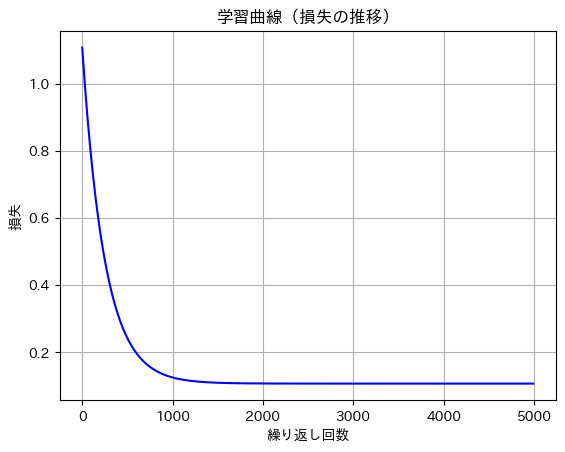

In [49]:
plt.plot(history[:, 0], history[:, 1], c='b')
plt.xlabel('繰り返し回数')
plt.ylabel('損失')
plt.title("学習曲線（損失の推移）")
plt.grid()
plt.show()


### 散布図と相関直線

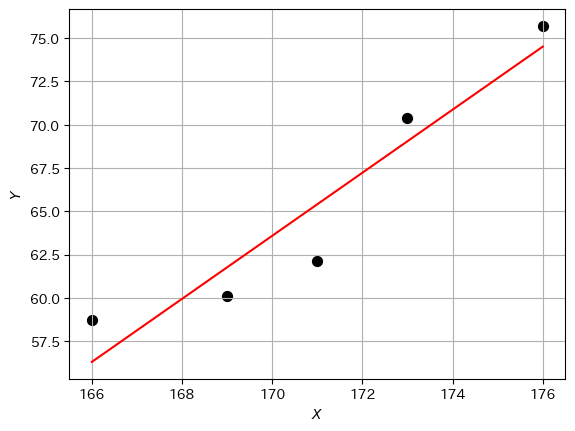

In [50]:
# numpyは勾配なんて知らないので，detachで計算グラフから切り離す．元の計算グラフが消えたりはしない．
X_np = X.detach().numpy() * x_std + x_mean
Y_np = Y.detach().numpy() * y_std + y_mean

y_pred = pred(X)
y_np = y_pred.detach().numpy() * y_std + y_mean

# 昇順のインデックス
idx = np.argsort(X_np)

plt.scatter(X_np, Y_np, c='k', s=50)
plt.plot(X_np[idx], y_np[idx], c='r')

plt.xlabel('$X$')
plt.ylabel('$Y$')
plt.grid()
plt.show()


# 最適化関数の利用による改良
パラメータの更新をコードで直接行ってきたが，通常の機械学習モデルでは「最適化関数」を経由して更新を行う．

## 初期化

In [77]:
W = torch.tensor(1.0, requires_grad=True, dtype=torch.float32)
B = torch.tensor(1.0, requires_grad=True, dtype=torch.float32)

num_epochs = 1000 # 繰り返し回数
lr = 0.001 # 学習率

# optimizerとしてSGD（確率的勾配降下法）を指定する．
optimizer = optim.SGD([W, B], lr=lr)

# 損失の記録用配列
history = np.zeros((0, 2)) # 2個の値を1セットとして，あとからどんどん追加する．


## ループ処理

In [78]:
for epoch in range(num_epochs):
    Yp = pred(X) # 予測計算
    loss = mse(Yp, Y) # 損失計算
    loss.backward() # 勾配計算

    optimizer.step() # パラメータ修正（自分で引き算を書いていた部分）
    optimizer.zero_grad() # 勾配値初期化（自分で.grad.zero_()を呼んでいた部分）

    # 損失の記録
    if (epoch % 10 == 0):
        item = np.array([epoch, loss.item()])
        history = np.vstack((history, item)) # vertical stack: 行を追加する．引数で「配列の集合」を渡す．集合だから幾つでも渡せるの！
        print(f"epoch = {epoch}, loss = {loss:.4f}")


epoch = 0, loss = 1.1085
epoch = 10, loss = 1.0692
epoch = 20, loss = 1.0313
epoch = 30, loss = 0.9950
epoch = 40, loss = 0.9601
epoch = 50, loss = 0.9266
epoch = 60, loss = 0.8943
epoch = 70, loss = 0.8634
epoch = 80, loss = 0.8336
epoch = 90, loss = 0.8051
epoch = 100, loss = 0.7776
epoch = 110, loss = 0.7512
epoch = 120, loss = 0.7259
epoch = 130, loss = 0.7015
epoch = 140, loss = 0.6781
epoch = 150, loss = 0.6557
epoch = 160, loss = 0.6341
epoch = 170, loss = 0.6133
epoch = 180, loss = 0.5934
epoch = 190, loss = 0.5743
epoch = 200, loss = 0.5559
epoch = 210, loss = 0.5382
epoch = 220, loss = 0.5212
epoch = 230, loss = 0.5049
epoch = 240, loss = 0.4892
epoch = 250, loss = 0.4742
epoch = 260, loss = 0.4597
epoch = 270, loss = 0.4458
epoch = 280, loss = 0.4325
epoch = 290, loss = 0.4196
epoch = 300, loss = 0.4073
epoch = 310, loss = 0.3955
epoch = 320, loss = 0.3841
epoch = 330, loss = 0.3731
epoch = 340, loss = 0.3626
epoch = 350, loss = 0.3526
epoch = 360, loss = 0.3429
epoch = 370,

## 学習後のパラメータ
最適化関数の仕事を自分で実装した時と全く同じ値が出る．実は，自分で実装したのはSGD（確率的勾配降下法）だったのだ．

In [79]:
# パラメータの最終値
print('W =', W.item())
print('B =', B.item())

# 損失の確認
print(f"初期状態: 損失: {history[0, 1]:.4f}")
print(f"最終状態: 損失: {history[-1, 1]:.4f}")


W = 0.9530670046806335
B = 0.1350644826889038
初期状態: 損失: 1.1085
最終状態: 損失: 0.1246


## 最適化関数のPros：チューニングの容易さ
最適化関数を導入するメリットは，コーディングの簡素化だけではない．例えば，momentum（学習を速くするアルゴリズム）を容易に利用できるようになる．

In [82]:
# 初期化

W = torch.tensor(1.0, requires_grad=True, dtype=torch.float32)
B = torch.tensor(1.0, requires_grad=True, dtype=torch.float32)

num_epochs = 1000
lr = 0.001 # 学習率

optimizer = optim.SGD([W, B], lr=lr, momentum=0.9) # チューニングあり

history2 = np.zeros((0, 2)) # 損失記録用の配列

# ループ

for epoch in range(num_epochs):
    Yp = pred(X)
    loss = mse(Yp, Y)
    loss.backward()

    optimizer.step()
    optimizer.zero_grad()

    if (epoch % 10 == 0):
        item = np.array([epoch, loss.item()])
        history2 = np.vstack((history2, item))
        print(f"epoch = {epoch}, loss = {loss:.4f}")


epoch = 0, loss = 1.1085
epoch = 10, loss = 0.9520
epoch = 20, loss = 0.7044
epoch = 30, loss = 0.4946
epoch = 40, loss = 0.3472
epoch = 50, loss = 0.2519
epoch = 60, loss = 0.1929
epoch = 70, loss = 0.1573
epoch = 80, loss = 0.1360
epoch = 90, loss = 0.1234
epoch = 100, loss = 0.1161
epoch = 110, loss = 0.1117
epoch = 120, loss = 0.1092
epoch = 130, loss = 0.1077
epoch = 140, loss = 0.1068
epoch = 150, loss = 0.1063
epoch = 160, loss = 0.1060
epoch = 170, loss = 0.1058
epoch = 180, loss = 0.1057
epoch = 190, loss = 0.1057
epoch = 200, loss = 0.1056
epoch = 210, loss = 0.1056
epoch = 220, loss = 0.1056
epoch = 230, loss = 0.1056
epoch = 240, loss = 0.1056
epoch = 250, loss = 0.1056
epoch = 260, loss = 0.1056
epoch = 270, loss = 0.1056
epoch = 280, loss = 0.1056
epoch = 290, loss = 0.1056
epoch = 300, loss = 0.1056
epoch = 310, loss = 0.1056
epoch = 320, loss = 0.1056
epoch = 330, loss = 0.1056
epoch = 340, loss = 0.1056
epoch = 350, loss = 0.1056
epoch = 360, loss = 0.1056
epoch = 370,

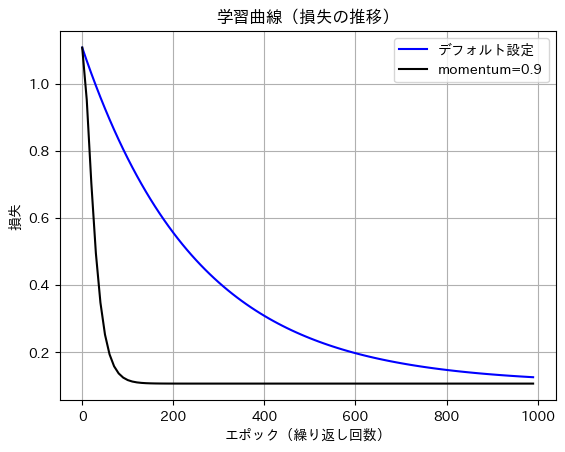

In [83]:
plt.plot(history[:, 0], history[:, 1], c='b', label='デフォルト設定')
plt.plot(history2[:, 0], history2[:, 1], c='k', label='momentum=0.9')
plt.xlabel("エポック（繰り返し回数）")
plt.ylabel("損失")
plt.title("学習曲線（損失の推移）")
plt.legend()
plt.grid()
plt.show()
